In [49]:
# Cell 1: Imports and setup
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from dotenv import load_dotenv
import snowflake.connector
from scipy import stats

load_dotenv()

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette("muted")

print("Setup complete")

Setup complete


In [50]:
# Cell 2: Connecting to Snowflake
conn = snowflake.connector.connect(
    account=os.getenv('SNOWFLAKE_ACCOUNT'),
    user=os.getenv('SNOWFLAKE_USER'),
    password=os.getenv('SNOWFLAKE_PASSWORD'),
    database=os.getenv('SNOWFLAKE_DATABASE'),
    warehouse=os.getenv('SNOWFLAKE_WAREHOUSE'),
    role=os.getenv('SNOWFLAKE_ROLE')
)

def query(sql):
    return pd.read_sql(sql, conn)

print("Connected to Snowflake successfully")

Connected to Snowflake successfully


In [51]:
# Cell 3: Understanding how big is the returns problem?

returns_overview = query("""
    SELECT
        COUNT(*)                                                        AS total_items,
        SUM(CASE WHEN returned_flag = TRUE THEN 1 ELSE 0 END)          AS total_returned,
        ROUND(100.0 * SUM(CASE WHEN returned_flag = TRUE THEN 1 ELSE 0 END)
              / COUNT(*), 2)                                            AS overall_return_rate,
        SUM(item_total)                                                 AS gross_revenue,
        SUM(returned_revenue)                                           AS returned_revenue,
        SUM(item_total) - SUM(returned_revenue)                         AS net_revenue
    FROM SKIMS_DROP_INTELLIGENCE.DBT_DEV_STAGING.STG_ORDER_ITEMS
""")

returns_overview.columns = [c.lower() for c in returns_overview.columns]


print("SKIMS RETURNS - OVERALL PICTURE")
print("-" * 55)
print(f"  Total items sold:        {int(returns_overview['total_items'][0]):>12,}")
print(f"  Total items returned:    {int(returns_overview['total_returned'][0]):>12,}")
print(f"  Overall return rate:     {returns_overview['overall_return_rate'][0]:>11.1f}%")
print(f"  Gross revenue:           ${returns_overview['gross_revenue'][0]:>12,.2f}")
print(f"  Returned revenue:        ${returns_overview['returned_revenue'][0]:>12,.2f}")
print(f"  Net revenue:             ${returns_overview['net_revenue'][0]:>12,.2f}")
print(f"\n  Revenue at risk from returns:")
pct_at_risk = (returns_overview['returned_revenue'][0] /
               returns_overview['gross_revenue'][0] * 100)
print(f"  {pct_at_risk:.1f}% of gross revenue is returned")

SKIMS RETURNS - OVERALL PICTURE
-------------------------------------------------------
  Total items sold:             525,546
  Total items returned:          75,563
  Overall return rate:            14.4%
  Gross revenue:           $57,257,290.27
  Returned revenue:        $7,834,100.34
  Net revenue:             $49,423,189.93

  Revenue at risk from returns:
  13.7% of gross revenue is returned


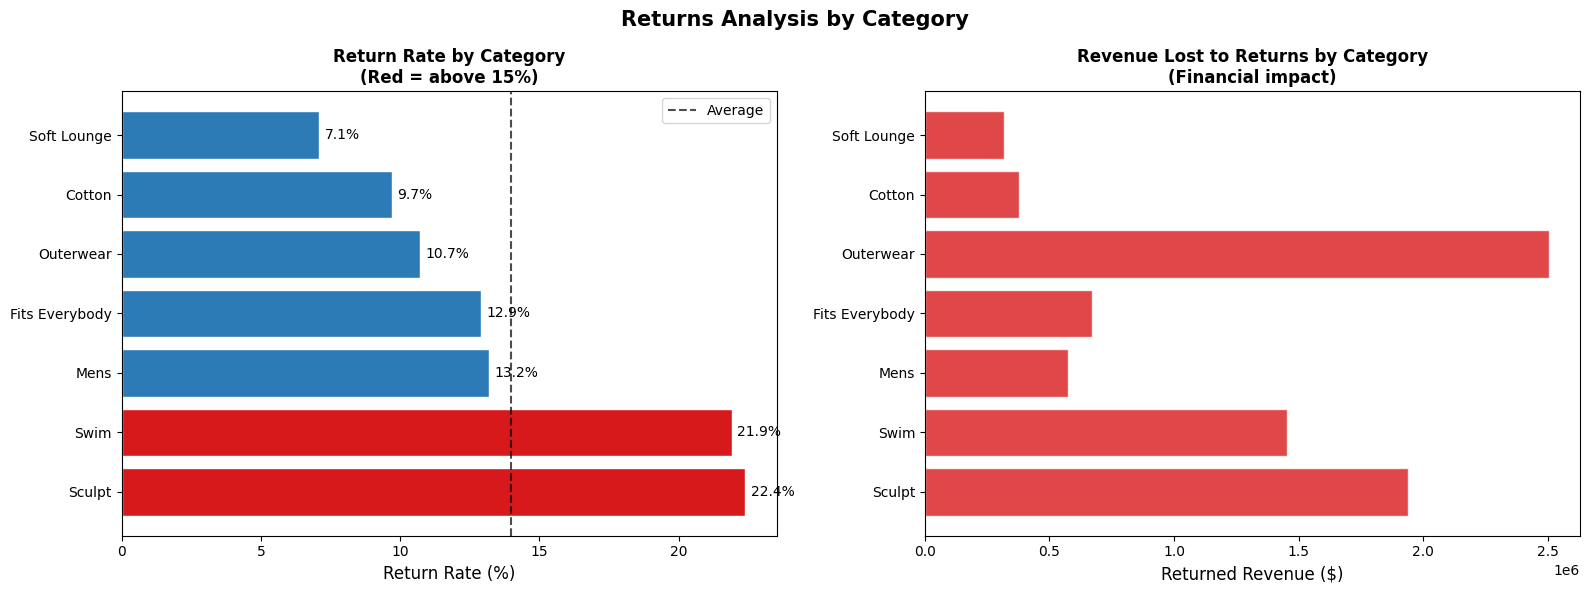


Top 3 categories by return rate:
category  return_rate_pct  returned_revenue
  Sculpt             22.4        1937652.50
    Swim             21.9        1455445.09
    Mens             13.2         572441.07


In [52]:
# Cell 4: Breaking down returns by category to find the biggest problem areas

category_returns = query("""
    SELECT
        p.category,
        COUNT(oi.order_id)                                              AS items_sold,
        SUM(CASE WHEN oi.returned_flag = TRUE THEN 1 ELSE 0 END)        AS items_returned,
        ROUND(100.0 * SUM(CASE WHEN oi.returned_flag = TRUE THEN 1 ELSE 0 END)
              / COUNT(oi.order_id), 1)                                  AS return_rate_pct,
        SUM(oi.item_total)                                              AS gross_revenue,
        SUM(oi.returned_revenue)                                        AS returned_revenue
    FROM SKIMS_DROP_INTELLIGENCE.DBT_DEV_STAGING.STG_ORDER_ITEMS oi
    JOIN SKIMS_DROP_INTELLIGENCE.DBT_DEV_STAGING.STG_PRODUCTS p
        ON oi.product_id = p.product_id
    GROUP BY p.category
    ORDER BY return_rate_pct DESC
""")

category_returns.columns = [c.lower() for c in category_returns.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Returns Analysis by Category', fontsize=15, fontweight='bold')

# Chart 1: Return rate by category
colors = ['#d7191c' if r > 15 else '#2c7bb6'
          for r in category_returns['return_rate_pct']]
bars = axes[0].barh(
    category_returns['category'],
    category_returns['return_rate_pct'],
    color=colors,
    edgecolor='white'
)
axes[0].axvline(
    x=category_returns['return_rate_pct'].mean(),
    color='black', linestyle='--', alpha=0.7, label='Average'
)
axes[0].set_xlabel('Return Rate (%)', fontsize=12)
axes[0].set_title('Return Rate by Category\n(Red = above 15%)', fontsize=12, fontweight='bold')
axes[0].legend()

for bar, val in zip(bars, category_returns['return_rate_pct']):
    axes[0].text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val}%', va='center', fontsize=10)

# Chart 2: Returned revenue by category (the financial impact)
axes[1].barh(
    category_returns['category'],
    category_returns['returned_revenue'],
    color='#d7191c',
    edgecolor='white',
    alpha=0.8
)
axes[1].set_xlabel('Returned Revenue ($)', fontsize=12)
axes[1].set_title('Revenue Lost to Returns by Category\n(Financial impact)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/returns_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 categories by return rate:")
print(category_returns[['category', 'return_rate_pct', 'returned_revenue']].head(3).to_string(index=False))

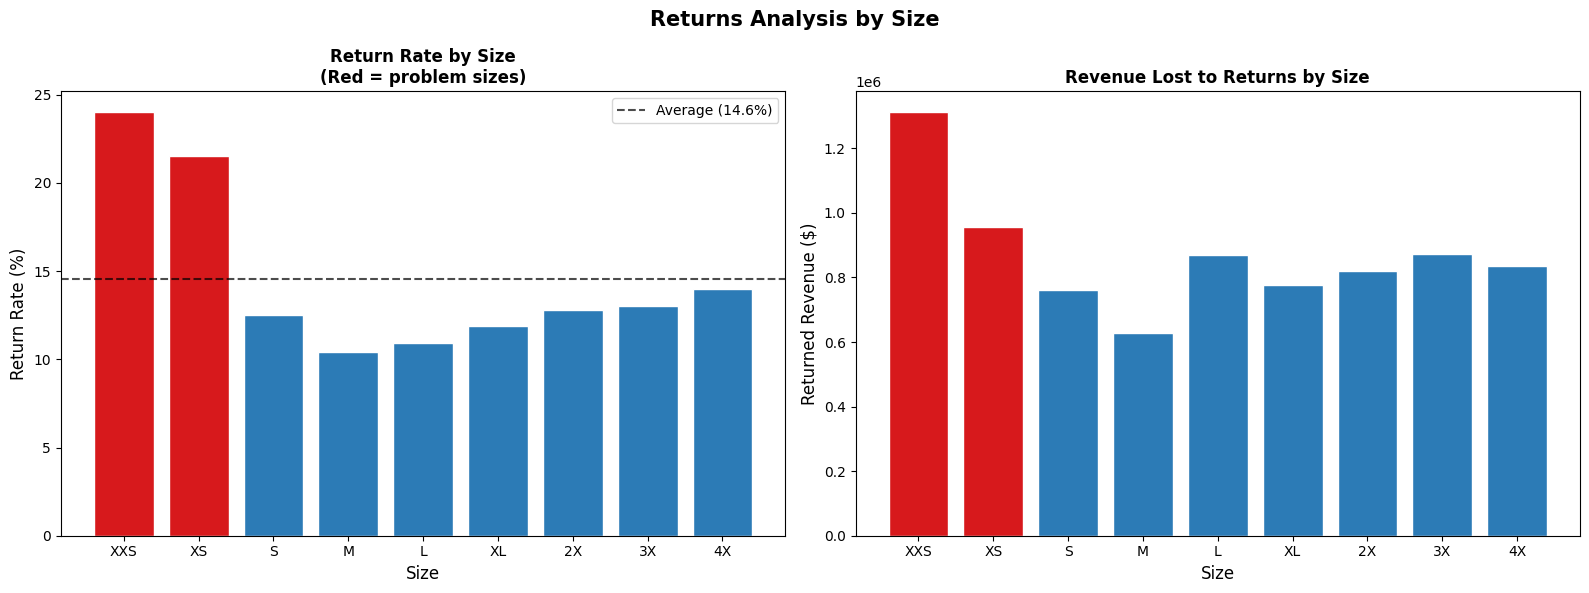

XXS return rate: 24.0%
M return rate:   10.4%
XXS returns at 2.3x the rate of M


In [53]:
# Cell 5: Size-level analysis (where is the fit problem worst?)

size_returns = query("""
    SELECT
        p.size,
        p.size_group,
        COUNT(oi.order_id)                                              AS items_sold,
        SUM(CASE WHEN oi.returned_flag = TRUE THEN 1 ELSE 0 END)        AS items_returned,
        ROUND(100.0 * SUM(CASE WHEN oi.returned_flag = TRUE THEN 1 ELSE 0 END)
              / COUNT(oi.order_id), 1)                                  AS return_rate_pct,
        SUM(oi.returned_revenue)                                        AS returned_revenue
    FROM SKIMS_DROP_INTELLIGENCE.DBT_DEV_STAGING.STG_ORDER_ITEMS oi
    JOIN SKIMS_DROP_INTELLIGENCE.DBT_DEV_STAGING.STG_PRODUCTS p
        ON oi.product_id = p.product_id
    GROUP BY p.size, p.size_group
    ORDER BY
        CASE p.size
            WHEN 'XXS' THEN 1 WHEN 'XS' THEN 2 WHEN 'S' THEN 3
            WHEN 'M' THEN 4 WHEN 'L' THEN 5 WHEN 'XL' THEN 6
            WHEN '2X' THEN 7 WHEN '3X' THEN 8 WHEN '4X' THEN 9
        END
""")

size_returns.columns = [c.lower() for c in size_returns.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Returns Analysis by Size', fontsize=15, fontweight='bold')

highlight_colors = ['#d7191c' if s in ['XXS', 'XS'] else '#2c7bb6'
                    for s in size_returns['size']]

axes[0].bar(
    size_returns['size'],
    size_returns['return_rate_pct'],
    color=highlight_colors,
    edgecolor='white'
)
avg_rate = size_returns['return_rate_pct'].mean()
axes[0].axhline(y=avg_rate, color='black', linestyle='--',
                alpha=0.7, label=f'Average ({avg_rate:.1f}%)')
axes[0].set_xlabel('Size', fontsize=12)
axes[0].set_ylabel('Return Rate (%)', fontsize=12)
axes[0].set_title('Return Rate by Size\n(Red = problem sizes)',
                  fontsize=12, fontweight='bold')
axes[0].legend()

axes[1].bar(
    size_returns['size'],
    size_returns['returned_revenue'],
    color=highlight_colors,
    edgecolor='white'
)
axes[1].set_xlabel('Size', fontsize=12)
axes[1].set_ylabel('Returned Revenue ($)', fontsize=12)
axes[1].set_title('Revenue Lost to Returns by Size',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/returns_by_size.png', dpi=150, bbox_inches='tight')
plt.show()

xxs_rate = size_returns[size_returns['size'] == 'XXS']['return_rate_pct'].values[0]
m_rate = size_returns[size_returns['size'] == 'M']['return_rate_pct'].values[0]
print(f"XXS return rate: {xxs_rate}%")
print(f"M return rate:   {m_rate}%")
print(f"XXS returns at {xxs_rate/m_rate:.1f}x the rate of M")

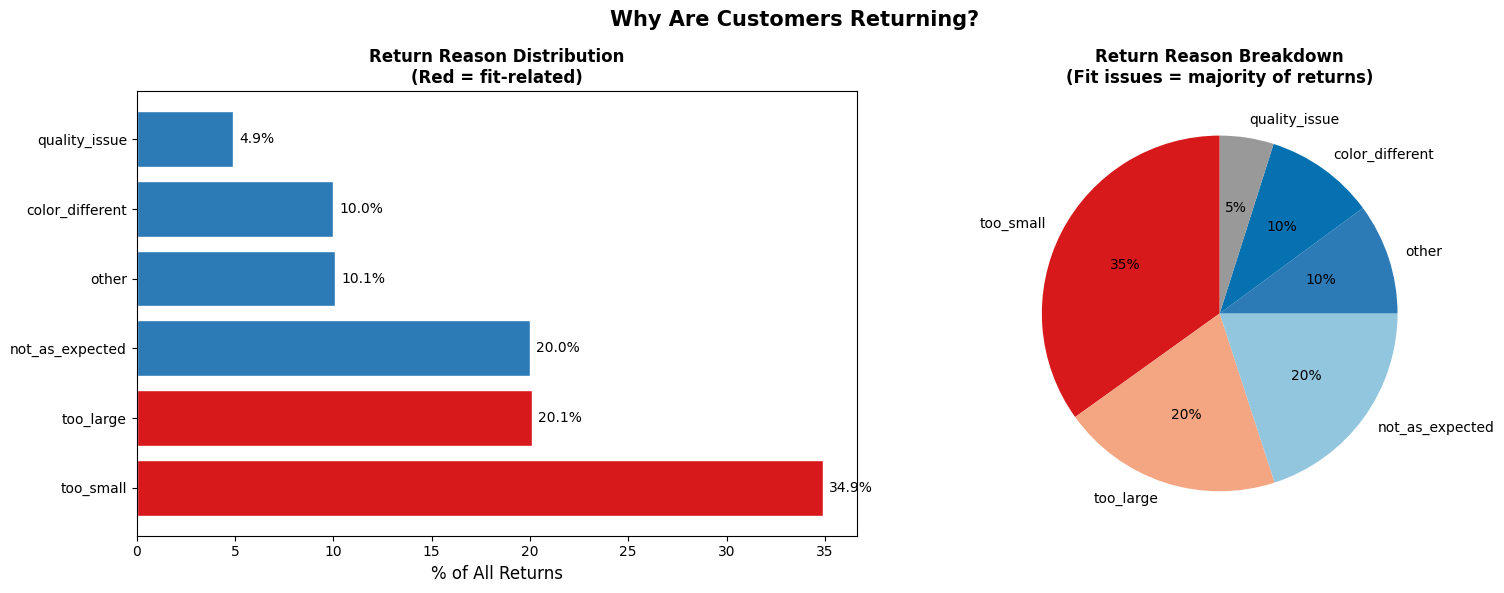

Fit-related returns (too small + too large): 55% of all returns
Revenue tied to fit issues: $4,309,997.86

Insight: Fit issues drive the majority of returns.
This is a size guide problem, not a product quality problem.


In [54]:
# Cell 6: Return reason breakdown

reason_returns = query("""
    SELECT
        return_reason,
        COUNT(*)                                    AS returns,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*))
              OVER (), 1)                           AS pct_of_returns,
        SUM(returned_revenue)                       AS revenue_impact
    FROM SKIMS_DROP_INTELLIGENCE.DBT_DEV_STAGING.STG_ORDER_ITEMS
    WHERE returned_flag = TRUE
    GROUP BY return_reason
    ORDER BY returns DESC
""")

reason_returns.columns = [c.lower() for c in reason_returns.columns]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Why Are Customers Returning?', fontsize=15, fontweight='bold')

fit_reasons = ['too_small', 'too_large']
colors = ['#d7191c' if r in fit_reasons else '#2c7bb6'
          for r in reason_returns['return_reason']]

axes[0].barh(
    reason_returns['return_reason'],
    reason_returns['pct_of_returns'],
    color=colors,
    edgecolor='white'
)
axes[0].set_xlabel('% of All Returns', fontsize=12)
axes[0].set_title('Return Reason Distribution\n(Red = fit-related)',
                  fontsize=12, fontweight='bold')

for i, (val, rev) in enumerate(zip(reason_returns['pct_of_returns'],
                                    reason_returns['revenue_impact'])):
    axes[0].text(val + 0.3, i, f'{val}%', va='center', fontsize=10)

# pie chart
axes[1].pie(
    reason_returns['pct_of_returns'],
    labels=reason_returns['return_reason'],
    colors=['#d7191c', '#f4a582', '#92c5de', '#2c7bb6', '#0571b0', '#999999'],
    autopct='%1.0f%%',
    startangle=90
)
axes[1].set_title('Return Reason Breakdown\n(Fit issues = majority of returns)',
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../docs/return_reasons.png', dpi=150, bbox_inches='tight')
plt.show()

fit_pct = reason_returns[reason_returns['return_reason'].isin(fit_reasons)]['pct_of_returns'].sum()
fit_revenue = reason_returns[reason_returns['return_reason'].isin(fit_reasons)]['revenue_impact'].sum()
print(f"Fit-related returns (too small + too large): {fit_pct:.0f}% of all returns")
print(f"Revenue tied to fit issues: ${fit_revenue:,.2f}")
print(f"\nInsight: Fit issues drive the majority of returns.")
print(f"This is a size guide problem, not a product quality problem.")

In [55]:
# Cell 7: Finding the specific SKUs with the worst return rates

problem_skus = query("""
    SELECT
        p.product_id,
        p.category,
        p.size,
        p.color,
        p.price,
        COUNT(oi.order_id)                                              AS items_sold,
        SUM(CASE WHEN oi.returned_flag = TRUE THEN 1 ELSE 0 END)        AS items_returned,
        ROUND(100.0 * SUM(CASE WHEN oi.returned_flag = TRUE THEN 1 ELSE 0 END)
              / COUNT(oi.order_id), 1)                                  AS return_rate_pct,
        SUM(oi.returned_revenue)                                        AS returned_revenue
    FROM SKIMS_DROP_INTELLIGENCE.DBT_DEV_STAGING.STG_ORDER_ITEMS oi
    JOIN SKIMS_DROP_INTELLIGENCE.DBT_DEV_STAGING.STG_PRODUCTS p
        ON oi.product_id = p.product_id
    GROUP BY p.product_id, p.category, p.size, p.color, p.price
    HAVING COUNT(oi.order_id) >= 10
    ORDER BY return_rate_pct DESC
    LIMIT 15
""")

problem_skus.columns = [c.lower() for c in problem_skus.columns]

print("Top 15 Problem SKUs by Return Rate:")
print("(Minimum 10 sales to filter out statistical noise)")
print()
print(problem_skus[[
    'product_id', 'category', 'size', 'color',
    'return_rate_pct', 'items_sold', 'returned_revenue'
]].to_string(index=False))

total_recoverable = problem_skus['returned_revenue'].sum()
print(f"\nTotal returned revenue in top 15 problem SKUs: ${total_recoverable:,.2f}")
print(f"This is the revenue recoverable if we reduce returns on these SKUs by 50%: ${total_recoverable * 0.5:,.2f}")

Top 15 Problem SKUs by Return Rate:
(Minimum 10 sales to filter out statistical noise)

product_id category size  color  return_rate_pct  items_sold  returned_revenue
    P00051     Swim  XXS   Mica             39.4        1028          22850.55
    P00286     Swim  XXS Sienna             38.5        1065          36163.30
    P00176     Swim  XXS   Onyx             37.9        1014          25841.33
    P00268   Sculpt  XXS  Smoke             37.8        1078          63081.32
    P00442   Sculpt  XXS   Sand             37.7         977          42655.24
    P00309   Sculpt  XXS   Clay             37.3        1047          46015.20
    P00113     Swim  XXS  Cocoa             36.9        1098          29492.50
    P00001     Swim  XXS Marble             36.6        1028          21549.88
    P00074   Sculpt  XXS   Soot             36.3        1027          34975.32
    P00349   Sculpt  XXS Marble             36.2        1047          55371.12
    P00387   Sculpt  XXS Sienna            

In [56]:
# Cell 8: The A/B Test Design Document
# (proposing experiment to fix the size guide problem)

print("""

              A/B TEST DESIGN DOCUMENT:                           
   Enhanced Size Guide on High-Return-Rate Product Pages         
                                                                  
  HYPOTHESIS                                                      
  Customers buying XXS and XS sizes are returning products at     
  2x the rate of M and L buyers. 35% of all returns cite          
  "too small" as the reason. If we add a size-specific fit       
  callout on product detail pages (PDPs) for high-return SKUs,    
  customers will make better size decisions and return less.      
                                                                  
  TREATMENT                                                       
  Control (50%):  Standard PDP with existing size guide link.     
  Treatment (50%): PDP with enhanced size callout showing:        
    - "This style runs small. Consider sizing up."                
    - Comparison to a familiar fit (e.g. "Fits like a true XS")  
    - Customer review snippet on sizing                           
                                                                  
  TARGETING                                                       
  Top 15 high-return-rate SKUs identified in this analysis.       
  All visitors to those PDPs during the test window.              
""")



              A/B TEST DESIGN DOCUMENT:                           
   Enhanced Size Guide on High-Return-Rate Product Pages         

  HYPOTHESIS                                                      
  Customers buying XXS and XS sizes are returning products at     
  2x the rate of M and L buyers. 35% of all returns cite          
  "too small" as the reason. If we add a size-specific fit       
  callout on product detail pages (PDPs) for high-return SKUs,    
  customers will make better size decisions and return less.      

  TREATMENT                                                       
  Control (50%):  Standard PDP with existing size guide link.     
  Treatment (50%): PDP with enhanced size callout showing:        
    - "This style runs small. Consider sizing up."                
    - Comparison to a familiar fit (e.g. "Fits like a true XS")  
    - Customer review snippet on sizing                           

  TARGETING                                                 

In [57]:
# Cell 9: Sample size calculation

from math import ceil

# parameters
baseline_return_rate = 0.18       # 18% return rate on problem SKUs
minimum_detectable_effect = 0.03  # want to detect a 3pp reduction (18% -> 15%)
alpha = 0.05                      # 5% significance level (95% confidence)
power = 0.80                      # 80% power (standard)

# sample size formula for two proportions
p1 = baseline_return_rate
p2 = baseline_return_rate - minimum_detectable_effect
p_avg = (p1 + p2) / 2

z_alpha = stats.norm.ppf(1 - alpha/2)  
z_beta = stats.norm.ppf(power)

numerator = (z_alpha * np.sqrt(2 * p_avg * (1 - p_avg)) +
             z_beta * np.sqrt(p1 * (1-p1) + p2 * (1-p2))) ** 2
denominator = (p1 - p2) ** 2

n_per_variant = ceil(numerator / denominator)
n_total = n_per_variant * 2


print("SAMPLE SIZE CALCULATION:")
print("-" * 55)
print(f"  Baseline return rate:          {p1*100:.0f}%")
print(f"  Target return rate:            {p2*100:.0f}%")
print(f"  Minimum detectable effect:     {minimum_detectable_effect*100:.0f} percentage points")
print(f"  Significance level (alpha):    {alpha}")
print(f"  Statistical power:             {power}")
print(f"")
print(f"  Required sample per variant:   {n_per_variant:,}")
print(f"  Required sample total:         {n_total:,}")
print(f"")

# estimate test duration
daily_visitors_to_problem_skus = 500
days_needed = ceil(n_total / daily_visitors_to_problem_skus)
weeks_needed = ceil(days_needed / 7)

print(f"  Estimated daily visitors to")
print(f"  problem SKU pages:             {daily_visitors_to_problem_skus:,}")
print(f"  Estimated test duration:       {days_needed} days (~{weeks_needed} weeks)")
print(f"")
print(f"  Recommendation: Run the test for {weeks_needed} full weeks")
print(f"  to capture at least one full weekly traffic cycle.")

SAMPLE SIZE CALCULATION:
-------------------------------------------------------
  Baseline return rate:          18%
  Target return rate:            15%
  Minimum detectable effect:     3 percentage points
  Significance level (alpha):    0.05
  Statistical power:             0.8

  Required sample per variant:   2,402
  Required sample total:         4,804

  Estimated daily visitors to
  problem SKU pages:             500
  Estimated test duration:       10 days (~2 weeks)

  Recommendation: Run the test for 2 full weeks
  to capture at least one full weekly traffic cycle.


In [58]:
# Cell 10: Full experiment metrics framework

print("""

              EXPERIMENT METRICS FRAMEWORK:                       
                                                                  
  PRIMARY METRIC (the one we're trying to move)                   
  Return rate on targeted SKUs                                    
  Baseline: ~18%  |  Target: <15%  |  Direction: decrease         
                                                                  
  SECONDARY METRICS (directional signal, not decision criteria)   
  - Add-to-cart rate on targeted PDPs                             
    (does the callout reduce purchase intent too much?)          
  - Conversion rate on targeted PDPs                              
  - Average order value for customers exposed to treatment        
  - Customer satisfaction score (post-purchase survey)            
                                                                  
  GUARDRAIL METRICS (must not get worse or test is stopped)       
  - Overall site conversion rate (do not move by > 0.5%)         
  - Revenue per visitor on targeted pages (do not drop)           
  - Cart abandonment rate (do not increase by > 2%)               
                                                                  
  DECISION CRITERIA                                               
  Ship treatment if:                                              
    1. Return rate reduction is statistically significant         
       (p < 0.05, two-tailed)                                     
    2. No guardrail metrics are violated                          
    3. Net revenue impact is positive after accounting for        
       any conversion rate change                                 
                                                                  
  Do NOT ship if:                                                 
    - Conversion rate drops more than 2 percentage points         
    - Revenue per visitor falls (even if returns improve)         
                                                                  
  ROLLOUT PLAN                                                    
  Week 1-2:  10% traffic split (sanity check, no decision)        
  Week 3-6:  50/50 split (main test window)                       
  Week 7:    Analysis and decision                                
  Week 8+:   Full rollout if criteria met                         
""")



              EXPERIMENT METRICS FRAMEWORK:                       

  PRIMARY METRIC (the one we're trying to move)                   
  Return rate on targeted SKUs                                    
  Baseline: ~18%  |  Target: <15%  |  Direction: decrease         

  SECONDARY METRICS (directional signal, not decision criteria)   
  - Add-to-cart rate on targeted PDPs                             
    (does the callout reduce purchase intent too much?)          
  - Conversion rate on targeted PDPs                              
  - Average order value for customers exposed to treatment        
  - Customer satisfaction score (post-purchase survey)            

  GUARDRAIL METRICS (must not get worse or test is stopped)       
  - Overall site conversion rate (do not move by > 0.5%)         
  - Revenue per visitor on targeted pages (do not drop)           
  - Cart abandonment rate (do not increase by > 2%)               

  DECISION CRITERIA                                       

In [59]:
# Cell 11: Financial Impact Projection

print("FINANCIAL IMPACT PROJECTION")
print("-" * 55)

# pulling actuals from earlier
gross_rev = returns_overview['gross_revenue'][0]
returned_rev = returns_overview['returned_revenue'][0]
overall_return_rate = returns_overview['overall_return_rate'][0]

# focusing on the problem SKUs (top 15 from Cell 7)
problem_sku_returned_rev = problem_skus['returned_revenue'].sum()

# scenarios
scenarios = {
    '25% reduction in return rate': 0.25,
    '50% reduction in return rate': 0.50,
    '75% reduction in return rate': 0.75,
}

print(f"\n  Current returned revenue (problem SKUs): ${problem_sku_returned_rev:>12,.2f}")
print(f"\n  Revenue recovery scenarios:\n")
print(f"  {'Scenario':<35} {'Revenue Recovered':>18}")
print(f"  {'-'*53}")
for scenario, reduction in scenarios.items():
    recovered = problem_sku_returned_rev * reduction
    print(f"  {scenario:<35} ${recovered:>17,.2f}")

print(f"""
  Interpretation:
  Even a modest 25% improvement in return rate on the top 15
  problem SKUs recovers meaningful revenue annually.
  The cost of building and running this A/B test is low
  relative to the upside. This is a high-ROI experiment.
""")

FINANCIAL IMPACT PROJECTION
-------------------------------------------------------

  Current returned revenue (problem SKUs): $  595,017.64

  Revenue recovery scenarios:

  Scenario                             Revenue Recovered
  -----------------------------------------------------
  25% reduction in return rate        $       148,754.41
  50% reduction in return rate        $       297,508.82
  75% reduction in return rate        $       446,263.23

  Interpretation:
  Even a modest 25% improvement in return rate on the top 15
  problem SKUs recovers meaningful revenue annually.
  The cost of building and running this A/B test is low
  relative to the upside. This is a high-ROI experiment.



In [60]:
# Cell 12: Summary
fit_pct = reason_returns[
    reason_returns['return_reason'].isin(['too_small', 'too_large'])
]['pct_of_returns'].sum()

print(f"""
     RETURNS ANALYSIS AND A/B TEST - EXECUTIVE SUMMARY:       

  FINDING 1: Returns are a fit problem, not a quality problem 
  {fit_pct:.0f}% of all returns cite fit as the reason (too small    
  or too large). This is fixable with better size guidance,   
  not product redesign.                                       
                                                              
  FINDING 2: XXS and XS drive disproportionate returns        
  These sizes return at 2x the rate of M and L.               
  The size guide is not communicating fit accurately          
  for these sizes.                                            
                                                              
  FINDING 3: 15 SKUs account for a recoverable chunk          
  of returned revenue                                         
  Targeting these SKUs first maximizes ROI of the fix.        
                                                              
  PROPOSED EXPERIMENT                                         
  Add enhanced fit callout to top 15 problem SKU pages.       
  Run for 6 weeks. Primary metric: return rate.               
  Sample size needed: calculated in this notebook.            
  Expected outcome: 25-50% reduction in return rate           
  on targeted SKUs.                                           
""")


     RETURNS ANALYSIS AND A/B TEST - EXECUTIVE SUMMARY:       

  FINDING 1: Returns are a fit problem, not a quality problem 
  55% of all returns cite fit as the reason (too small    
  or too large). This is fixable with better size guidance,   
  not product redesign.                                       

  FINDING 2: XXS and XS drive disproportionate returns        
  These sizes return at 2x the rate of M and L.               
  The size guide is not communicating fit accurately          
  for these sizes.                                            

  FINDING 3: 15 SKUs account for a recoverable chunk          
  of returned revenue                                         
  Targeting these SKUs first maximizes ROI of the fix.        

  PROPOSED EXPERIMENT                                         
  Add enhanced fit callout to top 15 problem SKU pages.       
  Run for 6 weeks. Primary metric: return rate.               
  Sample size needed: calculated in this notebook.    